# EDA IGDB – Proyecto IMT2200

En este notebook realizamos el análisis exploratorio de datos (EDA) para el
proyecto de IMT2200 basado en información de videojuegos obtenida desde IGDB.

**Objetivo general del proyecto**

Explorar qué factores se asocian al éxito de un videojuego (en términos de
rating y cantidad de reseñas), con foco en entregar recomendaciones a estudios
independientes sobre géneros, plataformas y ventanas de lanzamiento más
favorables.

**Preguntas específicas**

1. ¿Qué géneros han mantenido mayor popularidad en los últimos años?
2. ¿Qué diferencias hay entre juegos desarrollados por estudios AAA y juegos
   independientes u otros estudios en términos de éxito?
3. ¿Cómo influyen el género y el “estilo” de juego (modo de juego, perspectiva)
   en su visibilidad (cantidad de reseñas)?
4. ¿Qué plataformas parecen más favorables para juegos independientes?
5. ¿Existen ventanas temporales (año / mes) más atractivas para lanzar un indie?

El EDA de este notebook debe:

- Describir los datos disponibles y las transformaciones realizadas.
- Responder (o al menos aproximarse) a las preguntas anteriores.
- Motivar la construcción de un modelo de predicción de éxito en el siguiente
  notebook.


In [109]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
sns.set(style="whitegrid")

ruta_limpios = Path("..") / "data" / "processed"

df_juegos = pd.read_csv(ruta_limpios / "juegos_igdb_limpio.csv")
df_generos = pd.read_csv(ruta_limpios / "igdb_generos_limpio.csv")
df_plat = pd.read_csv(ruta_limpios / "igdb_plataformas_limpio.csv")
df_involved = pd.read_csv(ruta_limpios / "igdb_involved_companies_limpio.csv")
df_empresas = pd.read_csv(ruta_limpios / "igdb_empresas_limpio.csv")

df_juegos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186076 entries, 0 to 186075
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   186076 non-null  int64  
 1   game_modes           186076 non-null  object 
 2   genres               186076 non-null  object 
 3   involved_companies   186076 non-null  object 
 4   name                 186075 non-null  object 
 5   platforms            186076 non-null  object 
 6   slug                 186075 non-null  object 
 7   themes               186076 non-null  object 
 8   game_type            186076 non-null  int64  
 9   keywords             186076 non-null  object 
 10  player_perspectives  186076 non-null  object 
 11  rating               26228 non-null   float64
 12  rating_count         26228 non-null   float64
 13  total_rating         30345 non-null   float64
 14  total_rating_count   30345 non-null   float64
 15  fecha_lanzamiento

### Completitud de la información de rating

Antes de definir qué significa que un juego sea "exitoso", es importante ver
cuánta información de rating tenemos realmente disponible.

En particular, analizamos la proporción de valores faltantes en:

- `rating` y `rating_count` (evaluación "de usuario"),
- `total_rating` y `total_rating_count` (rating combinado y número de reseñas).

Esto nos permitirá decidir sobre qué subconjunto de juegos podemos medir
confiablemente el éxito.

In [110]:
cols_rating = ["rating", "rating_count", "total_rating", "total_rating_count"]

df_juegos[cols_rating].isna().mean().sort_values()


total_rating_count    0.836921
total_rating          0.836921
rating_count          0.859047
rating                0.859047
dtype: float64

In [111]:
n_total = len(df_juegos)
print("Total de juegos:", n_total)

for col in cols_rating:
    n_no_na = df_juegos[col].notna().sum()
    print(f"{col}: {n_no_na} no nulos ({n_no_na/n_total:.1%})")


Total de juegos: 186076
rating: 26228 no nulos (14.1%)
rating_count: 26228 no nulos (14.1%)
total_rating: 30345 no nulos (16.3%)
total_rating_count: 30345 no nulos (16.3%)


Conclusiones sobre completitud de ratings

- Solo aproximadamente el 15% de los juegos en el dataset cuenta con información completa de rating (`total_rating` y `total_rating_count`).
- Dado que la gran mayoría carece de evaluaciones, no es válido etiquetar ausencias como "no éxito"; se debe analizar el éxito únicamente sobre el subconjunto con datos de rating.
- Por tanto, todas las métricas de éxito y los modelos supervisados se entrenarán y evaluarán solo con las filas donde `tiene_info_rating` es True. El resto se mantiene para análisis descriptivos (volumen por año, género, plataforma).

## 2. Descripción general de los datos

En esta sección se presenta una visión general del dataset de juegos ya
limpio:

- Número total de juegos.
- Rango de años de lanzamiento considerados.
- Distribución básica de ratings y conteo de reseñas.
- Tablas auxiliares: géneros, plataformas, empresas y relaciones juego–empresa.


In [112]:
n_juegos = len(df_juegos)
anio_min = df_juegos["año_lanzamiento"].min()
anio_max = df_juegos["año_lanzamiento"].max()

print(f"Número de juegos en el dataset limpio: {n_juegos}")
print(f"Rango de años de lanzamiento: {anio_min}–{anio_max}")

df_juegos[["total_rating", "total_rating_count"]].describe()


Número de juegos en el dataset limpio: 186076
Rango de años de lanzamiento: 2000–2025


,total_rating,total_rating_count
count,30345.000000,30345.000000
mean,66.457835,26.130236
std,14.267189,135.414610
min,0.000000,0.000000
25%,59.857977,0.000000
50%,70.000000,2.000000
75%,76.774508,10.000000
max,100.000000,5350.000000


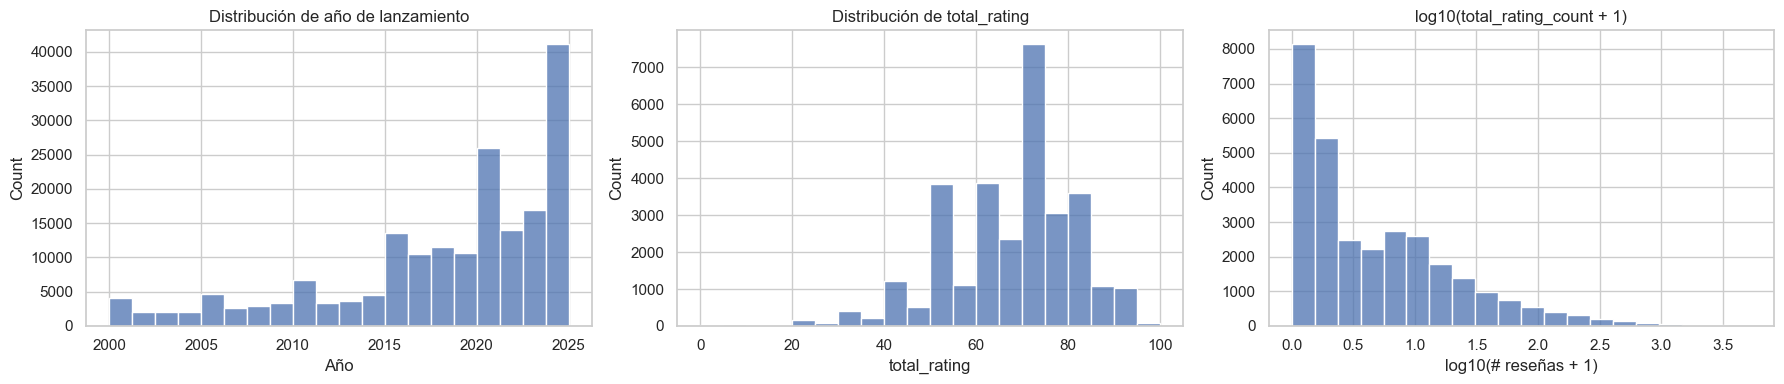

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# años
sns.histplot(df_juegos["año_lanzamiento"], bins=20, ax=axes[0])
axes[0].set_title("Distribución de año de lanzamiento")
axes[0].set_xlabel("Año")

# rating
sns.histplot(df_juegos["total_rating"].dropna(), bins=20, ax=axes[1])
axes[1].set_title("Distribución de total_rating")
axes[1].set_xlabel("total_rating")

# log10 de total_rating_count para ver mejor la cola
sns.histplot(
    np.log10(df_juegos["total_rating_count"].dropna()+1),
    bins=20,
    ax=axes[2]
)
axes[2].set_title("log10(total_rating_count + 1)")
axes[2].set_xlabel("log10(# reseñas + 1)")

plt.tight_layout()
plt.show()


Observaciones sobre distribuciones

- Año de lanzamiento: la distribución muestra concentración en años recientes, lo que indica un sesgo temporal hacia lanzamientos más nuevos en el dataset.
- `total_rating`: la distribución está relativamente centrada con tendencia hacia valores medios/altos; muchos títulos reciben calificaciones moderadas a buenas.
- `total_rating_count`: muy sesgada a la derecha (cola larga): pocos juegos acumulan muchas reseñas y la mayoría tiene pocas. Por eso visualizamos su logaritmo para apreciar mejor la variabilidad.
- Implicación: al modelar, conviene transformar variables de conteo (por ejemplo log10(#reseñas+1)) y controlar la heterogeneidad causada por la cola de reseñas.

## 3. Preparación de variables auxiliares

Antes del EDA más detallado, construimos algunas variables derivadas:

- Listas reales para columnas que vienen como texto (`genres`, `platforms`,
  `game_modes`).
- Tablas puente juego–género y juego–plataforma.
- Tipo de estudio (AAA vs no AAA) según publishers.
- Variable binaria de "éxito", que utilizaremos luego en el modelo.

In [114]:
def parsear_lista_literal(valor):
    if pd.isna(valor):
        return []
    if isinstance(valor, list):
        return valor
    s = str(valor).strip()
    if s in ("", "[]"):
        return []
    try:
        return literal_eval(s)
    except (SyntaxError, ValueError):
        return []

df_juegos["lista_generos"] = df_juegos["genres"].apply(parsear_lista_literal)
df_juegos["lista_plataformas"] = df_juegos["platforms"].apply(parsear_lista_literal)
df_juegos["lista_modos"] = df_juegos["game_modes"].apply(parsear_lista_literal)


In [115]:
# Tabla juego–género
registros_generos = []

for _, fila in df_juegos[["id", "lista_generos"]].iterrows():
    for g in fila["lista_generos"]:
        registros_generos.append({"id_juego": fila["id"], "id_genero": int(g)})

df_juegos_generos = pd.DataFrame(registros_generos)

df_juegos_generos = df_juegos_generos.merge(
    df_generos.rename(columns={"id": "id_genero", "name": "nombre_genero"}),
    on="id_genero",
    how="left"
)

df_juegos_generos.head()


,id_juego,id_genero,nombre_genero,slug
0,165498,2,Point-and-click,point-and-click
1,165498,9,Puzzle,puzzle
2,165498,31,Adventure,adventure
3,103013,31,Adventure,adventure
4,103013,32,Indie,indie


In [116]:
# Tabla juego–plataforma
registros_plat = []

for _, fila in df_juegos[["id", "lista_plataformas"]].iterrows():
    for p in fila["lista_plataformas"]:
        registros_plat.append({"id_juego": fila["id"], "id_plataforma": int(p)})

df_juegos_plat = pd.DataFrame(registros_plat)

df_juegos_plat = df_juegos_plat.merge(
    df_plat.rename(columns={"id": "id_plataforma", "name": "nombre_plataforma"}),
    on="id_plataforma",
    how="left"
)

df_juegos_plat.head()


,id_juego,id_plataforma,nombre_plataforma,slug,platform_family
0,165498,6,PC (Microsoft Windows),win,NaN
1,103013,6,PC (Microsoft Windows),win,NaN
2,338924,82,Web browser,browser,NaN
3,225575,34,Android,android,4.0
4,89658,6,PC (Microsoft Windows),win,NaN


### 3.3 Clasificación de tipo de estudio (AAA vs no AAA)

Usamos la tabla `involved_companies` y `empresas` para identificar los
publishers de cada juego. A partir de una lista curada de publishers AAA
(empresa grande, alto presupuesto), marcamos juegos "AAA" y el resto los
agrupamos como "No AAA / Indie".


In [117]:
# Subconjunto de relaciones donde la empresa actúa como publisher
df_pub = df_involved[df_involved["publisher"]].merge(
    df_empresas[["id", "name"]],
    left_on="company",
    right_on="id",
    how="left",
    suffixes=("", "_empresa"),
)

df_pub.head()


,id,company,developer,game,porting,publisher,supporting,id_empresa,name
0,342033,68045,False,364700,False,True,False,NaN,NaN
1,337692,66934,True,361757,False,True,False,NaN,NaN
2,341278,67833,True,363079,False,True,False,NaN,NaN
3,347480,36973,False,368934,False,True,False,NaN,NaN
4,349280,44384,True,370254,False,True,False,NaN,NaN


In [118]:
aaa_publishers = {
    "Electronic Arts",
    "EA Games",
    "Ubisoft",
    "Activision",
    "Activision Blizzard",
    "Nintendo",
    "Sony Interactive Entertainment",
    "Microsoft Studios",
    "Xbox Game Studios",
    "Square Enix",
    "Bandai Namco Entertainment",
    "Capcom",
    "SEGA",
    "Take-Two Interactive",
    "2K",
    "Bethesda Softworks",
    "Rockstar Games",
    "Warner Bros. Interactive Entertainment",
    "WB Games",
}

df_pub["es_aaa"] = df_pub["name"].isin(aaa_publishers)

resumen_pub = (
    df_pub.groupby("game")
    .agg(
        tiene_publisher=("publisher", "any"),
        tiene_publisher_aaa=("es_aaa", "any"),
    )
    .reset_index()
    .rename(columns={"game": "id_juego"})
)

df_juegos = df_juegos.merge(
    resumen_pub,
    left_on="id",
    right_on="id_juego",
    how="left",
)

df_juegos["tiene_publisher"] = df_juegos["tiene_publisher"].fillna(False)
df_juegos["tiene_publisher_aaa"] = df_juegos["tiene_publisher_aaa"].fillna(False)

df_juegos["tipo_estudio"] = np.select(
    [
        df_juegos["tiene_publisher_aaa"],
        df_juegos["tiene_publisher"] & ~df_juegos["tiene_publisher_aaa"],
    ],
    [
        "AAA",
        "No AAA",
    ],
    default="Sin publisher",
)

df_juegos["tipo_estudio"].value_counts()


C:\Users\Unidad Academica MC\AppData\Local\Temp\ipykernel_13488\3599635081.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_juegos["tiene_publisher"] = df_juegos["tiene_publisher"].fillna(False)
C:\Users\Unidad Academica MC\AppData\Local\Temp\ipykernel_13488\3599635081.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_juegos["tiene_publisher_aaa"] = df_juegos["tiene_publisher_aaa"].fillna(False)


tipo_estudio
Sin publisher    97760
No AAA           84539
AAA               3777
Name: count, dtype: int64

Comentario sobre clasificación de tipo de estudio

- Se definieron tres categorías: "AAA" (publishers grandes), "No AAA" (tiene publisher pero no AAA) y "Sin publisher".
- Esta clasificación permite comparar rendimiento y visibilidad entre estudios de distinto tamaño y usarla como variable explicativa en los modelos.
- "No AAA" y "Sin publisher" funcionan como proxies de estudios independientes, aunque pueden contener heterogeneidad interna.

### 3.4 Definición de variable de éxito

Definimos una variable binaria `exitoso` que indica si un juego puede
considerarse exitoso en términos de evaluación y visibilidad. Usaremos:

- `total_rating` como medida de calidad percibida.
- `total_rating_count` como aproximación a cuántas reseñas/atención tuvo.

Para fijar umbrales razonables, miramos la distribución de ambas columnas.


In [119]:
df_juegos[["total_rating", "total_rating_count"]].describe(percentiles=[0.5, 0.75, 0.9])

,total_rating,total_rating_count
count,30345.000000,30345.000000
mean,66.457835,26.130236
std,14.267189,135.414610
min,0.000000,0.000000
50%,70.000000,2.000000
75%,76.774508,10.000000
90%,82.389809,38.000000
max,100.000000,5350.000000


A partir de la distribución, elegimos umbrales (pueden ajustarse):

- `total_rating` ≥ 75 puntos.
- `total_rating_count` ≥ 10 reseñas.

Estos valores buscan capturar juegos bien evaluados y con suficiente volumen
de reseñas para no depender de pocas opiniones.

In [120]:
# 1) Marcamos qué juegos tienen info de rating usable
mask_valid = df_juegos["total_rating"].notna() & df_juegos["total_rating_count"].notna()
df_juegos["tiene_info_rating"] = mask_valid

n_total = len(df_juegos)
n_valid = mask_valid.sum()

print("Total de juegos:", n_total)
print("Con info de total_rating + total_rating_count:",
      n_valid, f"({n_valid/n_total:.1%})")

# 2) Elegimos umbrales para definir "éxito"
# (estos son razonables: rating alto y un mínimo de reseñas)
umbral_rating = 75
umbral_reviews = 10

cond_exito = (
    (df_juegos["total_rating"] >= umbral_rating) &
    (df_juegos["total_rating_count"] >= umbral_reviews)
)

# 3) Creamos la variable:
#    - NaN  -> no tengo info de rating (no lo considero para éxito)
#    - True -> cumple ambos umbrales
#    - False-> tiene info pero no cumple
df_juegos["exitoso"] = np.where(
    ~mask_valid, np.nan,              # sin datos -> desconocido
    np.where(cond_exito, True, False) # con datos -> True/False
)

df_juegos["exitoso"].value_counts(dropna=False)

Total de juegos: 186076
Con info de total_rating + total_rating_count: 30345 (16.3%)


exitoso
NaN    155731
0.0     26488
1.0      3857
Name: count, dtype: int64

**Comentario**

- Solo ~16 % de los juegos tiene `total_rating` y `total_rating_count`
  disponibles; sobre ese subconjunto trabajaremos la noción de éxito.
- Definimos como exitosos a los juegos con:
  - `total_rating` ≥ 75 puntos (rating alto respecto a la distribución), y
  - al menos 10 reseñas (`total_rating_count` ≥ 10), para evitar juegos con
    pocas opiniones.
- La variable `exitoso` queda como:
  - `True`  → juego con rating alto y suficiente número de reseñas,
  - `False` → juego con rating/visibilidad insuficiente,
  - `NaN`   → no contamos con información de rating, por lo que no podemos
    evaluar su éxito.
- En todos los análisis que involucren éxito utilizaremos únicamente las filas
  donde `exitoso` no es nulo.


## 4.1 Popularidad de géneros en el tiempo

Para responder a la primera pregunta, analizamos cómo ha evolucionado la
popularidad de los géneros en los últimos 10 años, medida como:

- número de lanzamientos por año y género, y
- proporción de juegos exitosos por género y año.


In [121]:
anio_max = df_juegos["año_lanzamiento"].max()
anio_min_10 = max(df_juegos["año_lanzamiento"].min(), anio_max - 9)

df_reciente = df_juegos[
    df_juegos["año_lanzamiento"].between(anio_min_10, anio_max)
].copy()

ids_recientes = df_reciente["id"].unique().tolist()

df_juegos_generos_reciente = df_juegos_generos[
    df_juegos_generos["id_juego"].isin(ids_recientes)
].copy()

# número de juegos por género
conteo_generos = (
    df_juegos_generos_reciente.groupby("nombre_genero")["id_juego"]
    .nunique()
    .sort_values(ascending=False)
)

top_generos = conteo_generos.head(8).index.tolist()
conteo_generos.head(10)


nombre_genero
Indie                 78151
Adventure             50917
Simulator             26244
Strategy              22588
Role-playing (RPG)    20671
Puzzle                15607
Arcade                12882
Platform               8827
Shooter                8550
Visual Novel           7449
Name: id_juego, dtype: int64

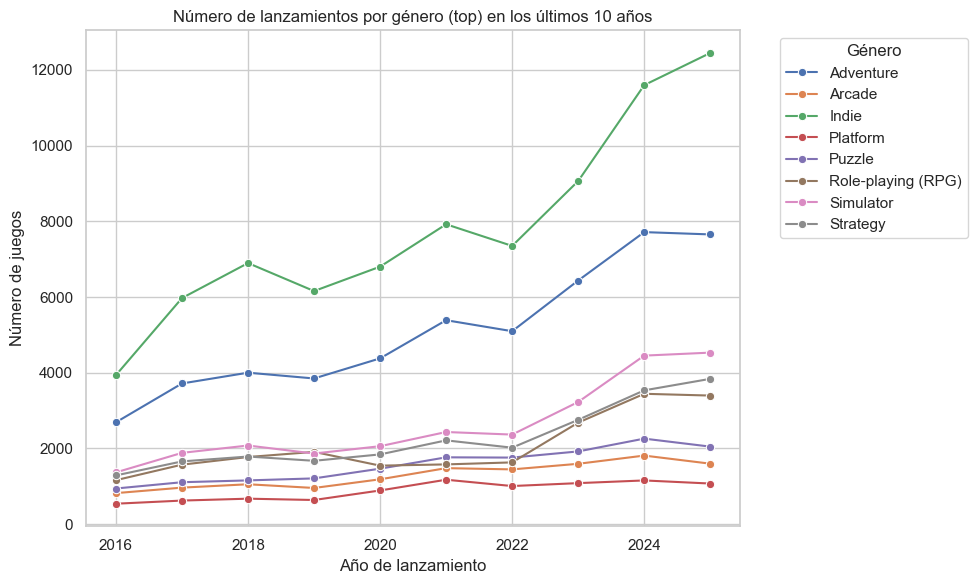

In [122]:
# Serie de tiempo: lanzamientos por año para géneros top
tabla_gen_anio = (
    df_juegos_generos_reciente.merge(
        df_reciente[["id", "año_lanzamiento"]],
        left_on="id_juego",
        right_on="id",
        how="left",
    )
    .query("nombre_genero in @top_generos")
    .groupby(["año_lanzamiento", "nombre_genero"])["id_juego"]
    .nunique()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=tabla_gen_anio,
    x="año_lanzamiento",
    y="id_juego",
    hue="nombre_genero",
    marker="o",
)
plt.title("Número de lanzamientos por género (top) en los últimos 10 años")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Número de juegos")
plt.legend(title="Género", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


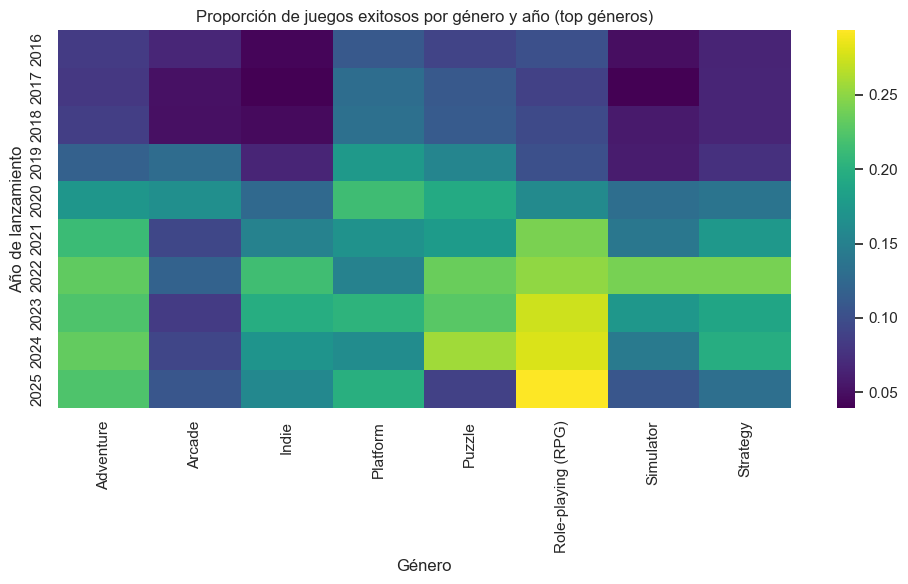

In [123]:
# Porcentaje de juegos exitosos por género y año
df_tmp = df_juegos_generos_reciente.merge(
    df_reciente[["id", "año_lanzamiento", "exitoso"]],
    left_on="id_juego",
    right_on="id",
    how="left",
)

df_tmp = df_tmp[df_tmp["nombre_genero"].isin(top_generos)]

tabla_exito = (
    df_tmp.groupby(["año_lanzamiento", "nombre_genero"])["exitoso"]
    .mean()
    .unstack("nombre_genero")
)

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_exito, annot=False, cmap="viridis")
plt.title("Proporción de juegos exitosos por género y año (top géneros)")
plt.xlabel("Género")
plt.ylabel("Año de lanzamiento")
plt.tight_layout()
plt.show()


- Aquí la proporción de éxitos está calculada solo entre los juegos que tienen
  rating y número de reseñas suficientes para evaluar éxito.
- Se observan géneros con muchos lanzamientos pero tasa de éxito relativamente
  baja, y otros con menos lanzamientos pero una tasa de éxito mayor, lo que
  podría indicar nichos atractivos para estudios independientes.
- Estos patrones serán importantes al construir el modelo: los géneros pueden
  ser una de las variables explicativas del éxito.

In [124]:
# Usamos solo juegos donde se puede evaluar éxito
df_val = df_juegos[df_juegos["exitoso"].notna()].copy()

resumen_tipo = (
    df_val.groupby("tipo_estudio")
    .agg(
        n_juegos=("id", "count"),
        rating_mediana=("total_rating", "median"),
        reseñas_mediana=("total_rating_count", "median"),
        p_exitosos=("exitoso", "mean"),
    )
    .sort_values("n_juegos", ascending=False)
)

resumen_tipo


,n_juegos,rating_mediana,reseñas_mediana,p_exitosos
tipo_estudio,,,,
No AAA,21197,70.000000,3.0,0.134170
Sin publisher,6902,70.000000,0.0,0.027528
AAA,2246,74.238807,21.0,0.366429


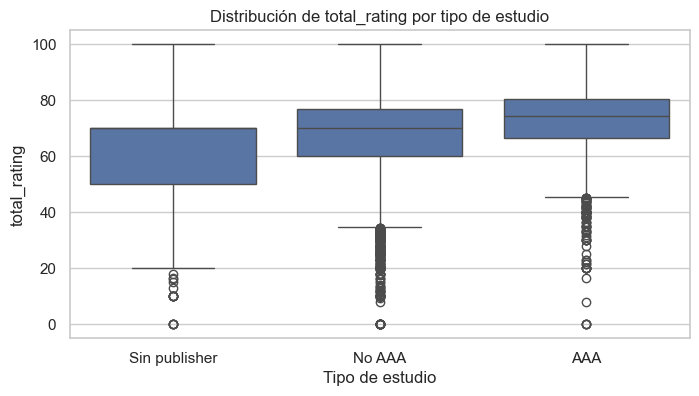

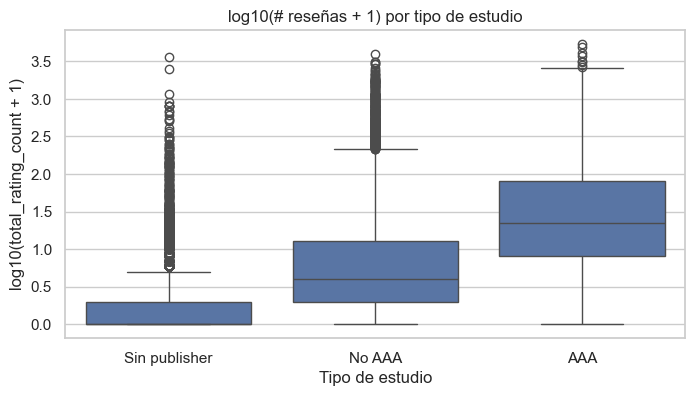

In [125]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_val, x="tipo_estudio", y="total_rating")
plt.title("Distribución de total_rating por tipo de estudio")
plt.xlabel("Tipo de estudio")
plt.ylabel("total_rating")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df_val[df_val["total_rating_count"].notna()],
    x="tipo_estudio",
    y=np.log10(df_val["total_rating_count"] + 1),
)
plt.title("log10(# reseñas + 1) por tipo de estudio")
plt.xlabel("Tipo de estudio")
plt.ylabel("log10(total_rating_count + 1)")
plt.show()


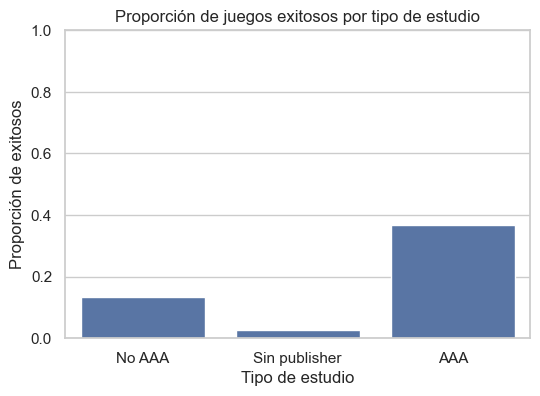

In [126]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=resumen_tipo.reset_index(),
    x="tipo_estudio",
    y="p_exitosos",
)
plt.title("Proporción de juegos exitosos por tipo de estudio")
plt.xlabel("Tipo de estudio")
plt.ylabel("Proporción de exitosos")
plt.ylim(0, 1)
plt.show()


Resultados clave entre tipos de estudio (solo juegos con rating)

- AAA tiende a mostrar medianas de `total_rating` y `total_rating_count` superiores a las de No AAA / Sin publisher, lo que sugiere mayor visibilidad y, en promedio, más reseñas.
- La proporción de juegos exitosos (`p_exitosos`) es mayor en AAA en comparación con No AAA/Sin publisher, aunque existen títulos independientes con alto rendimiento (solapamiento entre distribuciones).
- Implicación: el tipo de estudio aporta señal para predecir éxito, pero no determina completamente el resultado — otras variables (género, plataforma, mes) también son relevantes.

## 4.3 Plataformas y éxito de juegos independientes

Agrupamos plataformas en categorías amplias (PC, Consola, Móvil, Portátil,
Otras) y analizamos, solo para juegos No AAA / Sin publisher, en qué
plataformas se concentran más lanzamientos y cuál es la proporción de juegos
exitosos.


In [127]:
# Clasificación macro de plataforma
def categoria_plataforma(nombre):
    n = str(nombre).lower()
    if any(x in n for x in ["windows", "pc", "linux", "mac os"]):
        return "PC"
    if any(x in n for x in ["playstation", "xbox", "nintendo switch"]):
        return "Consola"
    if any(x in n for x in ["nintendo 3ds", "ps vita", "game boy"]):
        return "Portátil"
    if any(x in n for x in ["android", "ios", "iphone", "ipad", "mobile"]):
        return "Móvil"
    return "Otras"

df_plat = df_plat.rename(columns={"id": "id_plataforma"})
df_plat["categoria_plataforma"] = df_plat["name"].apply(categoria_plataforma)

df_juegos_plat = df_juegos_plat.merge(
    df_plat[["id_plataforma", "categoria_plataforma"]],
    on="id_plataforma",
    how="left",
)

df_juegos_plat.head()


,id_juego,id_plataforma,nombre_plataforma,slug,platform_family,categoria_plataforma
0,165498,6,PC (Microsoft Windows),win,NaN,PC
1,103013,6,PC (Microsoft Windows),win,NaN,PC
2,338924,82,Web browser,browser,NaN,Otras
3,225575,34,Android,android,4.0,Móvil
4,89658,6,PC (Microsoft Windows),win,NaN,PC


In [128]:
# Solo juegos no AAA / sin publisher (proxy de indies)
df_indies = df_juegos[
    (df_juegos["tipo_estudio"] != "AAA") & df_juegos["exitoso"].notna()
].copy()

df_indies_plat = df_juegos_plat[
    df_juegos_plat["id_juego"].isin(df_indies["id"])
].merge(
    df_indies[["id", "exitoso"]],
    left_on="id_juego",
    right_on="id",
    how="left",
)

resumen_plat_indie = (
    df_indies_plat.groupby("categoria_plataforma")
    .agg(
        n_juegos=("id_juego", "nunique"),
        p_exitosos=("exitoso", "mean"),
    )
    .sort_values("n_juegos", ascending=False)
)

min_juegos = 50
resumen_plat_indie_filtrado = resumen_plat_indie[
    resumen_plat_indie["n_juegos"] >= min_juegos
]


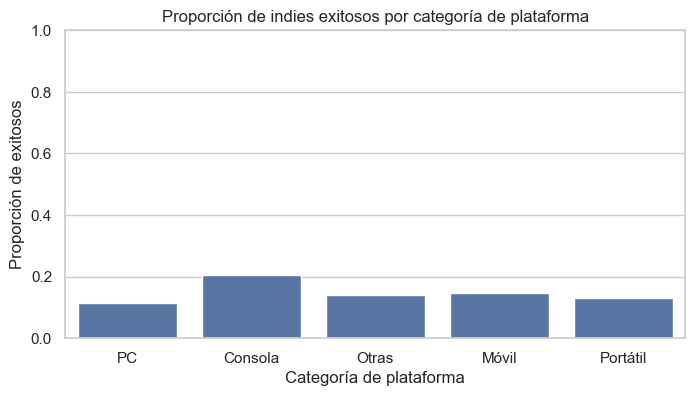

In [129]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=resumen_plat_indie_filtrado.reset_index(),
    x="categoria_plataforma",
    y="p_exitosos",
)
plt.title("Proporción de indies exitosos por categoría de plataforma")
plt.xlabel("Categoría de plataforma")
plt.ylabel("Proporción de exitosos")
plt.ylim(0, 1)
plt.show()


Conclusiones sobre plataformas para indies (filtrado ≥ 50 juegos)

- Tras agrupar plataformas en categorías, y analizar solo indies con rating, "Consola" muestra la mayor proporción de éxitos entre las categorías con suficiente muestra.
- "PC" suele ser la siguiente categoría con tasa de éxito razonable; "Móvil" presenta tasas más bajas en este dataset filtrado.
- Notar que categorías con pocos juegos fueron descartadas para evitar conclusiones inestables.
- Implicación práctica: para indies, lanzar en consolas (cuando sea viable) aparece como una ventana con mayor probabilidad de éxito relativo en este conjunto de datos.

Observaciones sobre ventanas temporales

- La distribución de lanzamientos indies por mes muestra variaciones a lo largo del año, pero los meses con muy pocos lanzamientos tienen estimaciones de proporción de éxito poco fiables.
- No se observa, en este análisis exploratorio, una única ventana claramente dominante tras filtrar por tamaño de muestra; hay meses con proporciones relativamente altas pero también con bajo volumen.
- Recomendación: para conclusiones más sólidas, aplicar pruebas estadísticas (p. ej. intervalos de confianza o tests de proporciones) o agrupar meses por estaciones para aumentar tamaño de muestra.

Conclusiones finales y recomendaciones para el modelado

Hallazgos principales:
- Solo ~15% de los juegos tiene información completa de rating; por ello el análisis de "éxito" y el modelado supervisado se realizarán sobre ese subconjunto.
- Géneros: existen géneros con alto volumen de lanzamientos pero baja tasa de éxito y géneros con menor volumen pero mayor proporción de éxitos — esto sugiere oportunidades de nicho para indies.
- Tipo de estudio: AAA suele tener mayor visibilidad y una tasa de éxito superior en promedio, aunque hay indies exitosos; la categoría de estudio es una variable predictiva relevante.
- Plataformas: para indies, las consolas muestran la mayor proporción de éxitos entre las categorías con muestra suficiente; PC es competitiva; móvil presenta menor tasa en este dataset.
- Temporalidad: no hay una ventana claramente dominante sin más análisis; meses con pocos lanzamientos producen estimaciones poco estables.

Implicaciones para el siguiente notebook (03_modelo_prediccion.ipynb):
- Construir el dataframe de modelado usando solo filas con `tiene_info_rating` True y `exitoso` como target binario.
- Features recomendadas: género (o one‑hot / embeddings), categoría de plataforma, tipo_estudio, mes y año de lanzamiento, número de plataformas soportadas, modos de juego, y variables derivadas (p. ej. log10(reseñas+1)).
- Tratar el desequilibrio de clases (pocas observaciones etiquetadas) con técnicas como estratificación, muestreo (SMOTE o submuestreo) y evaluación con métricas robustas (AUC, F1, precisión/recall).
- Validación: usar validación cruzada estratificada y analizar importancia de variables (permuta, SHAP) para obtener interpretabilidad útil para estudios independientes.

Acción práctica: en 03_modelo_prediccion.ipynb construir el set de entrenamiento con las transformaciones propuestas, prototipar un modelo simple (regresión logística y un árbol/RandomForest) y comparar desempeño y estabilidad.